In [44]:
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [32]:

sp500_ticker = yf.Ticker('^GSPC')
sp500 = sp500_ticker.history(start="1990-01-01", end="2025-02-07")


apple_ticker = yf.Ticker('AAPL')
apple = apple_ticker.history(start="1990-01-01", end="2025-02-07")

In [ ]:
# platinum ticker
platinum_ticker = yf.Ticker("PL=F")
platinum = platinum_ticker.history(start="2020-01-01")
platinum.reset_index(inplace=True)
platinum['Date'] = pd.to_datetime(platinum['Date']).dt.date

#### SOURCE ####
# https://fred.stlouisfed.org/series/EFFR
effr = pd.read_csv('EFFR.csv')
effr['observation_date'] = pd.to_datetime(effr['observation_date']).dt.date

# Consumer Price Index
cpi = web.DataReader("CPIAUCNS", "fred", start="2020-01-01", end=effr.observation_date.max())
cpi.reset_index(inplace=True)
cpi['DATE'] = pd.to_datetime(cpi['DATE']).dt.date

# U.S. Dollar Index (DXY)
dxy = yf.download("DX-Y.NYB", start="2020-01-01", interval="1d", end=effr.observation_date.max())
dxy.reset_index(inplace=True)
dxy['Date'] = pd.to_datetime(dxy['Date']).dt.date
dxy.columns = [x[0] for x in dxy.columns]


[*********************100%***********************]  1 of 1 completed


In [64]:
### FILTER DATES ###
platinum_data = platinum[platinum.Date >= effr.observation_date.min()]

# calculate daily returns
platinum_data['Returns'] = platinum_data['Close'].pct_change()
#### CALCULATE 30 DAY VOLATILITY #### 
platinum_data['Volatility'] = platinum_data['Returns'].rolling(window=30,min_periods=1).std()
platinum_data['Annual Volatility'] = platinum_data['Volatility'] * np.sqrt(252) 


### MERGE PLATINUM AND INTEREST RATE DATASET ###
df = platinum_data.merge(effr, how='inner', left_on='Date', right_on='observation_date').drop('observation_date',axis=1)


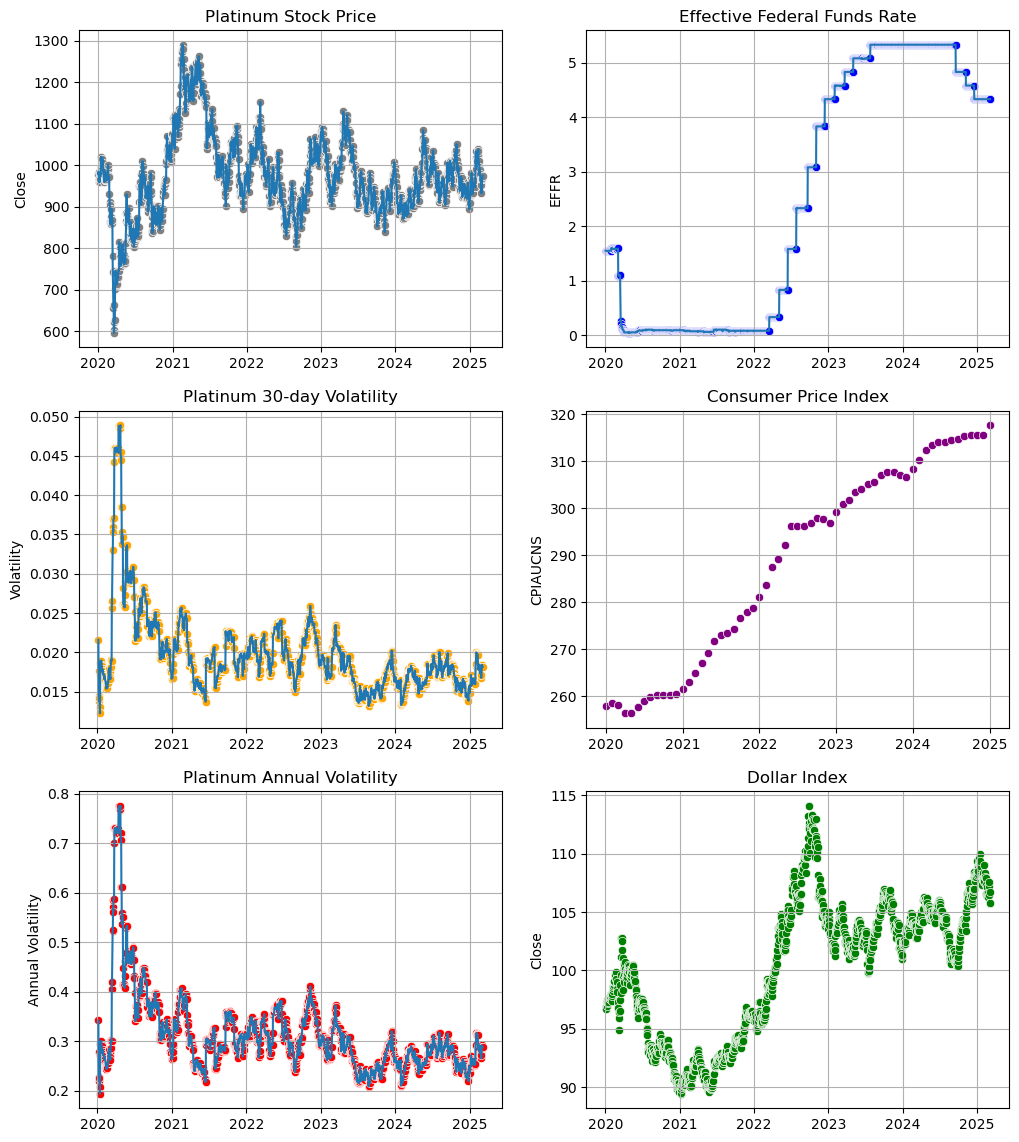

In [78]:
fig,axs = plt.subplots(3,2,figsize=(12,14))


sns.scatterplot(data=df,x='Date',y='Close',ax=axs[0,0],color='grey')
sns.lineplot(data=df,x='Date',y='Close',ax=axs[0,0])
axs[0,0].set_title(label='Platinum Stock Price')


sns.scatterplot(data=df,x='Date',y='Volatility',ax=axs[1,0],color='orange')
sns.lineplot(data=df,x='Date',y='Volatility',ax=axs[1,0])
axs[1,0].set_title(label='Platinum 30-day Volatility')

sns.scatterplot(data=df,x='Date',y='Annual Volatility',ax=axs[2,0],color='red')
sns.lineplot(data=df,x='Date',y='Annual Volatility',ax=axs[2,0])
axs[2,0].set_title(label='Platinum Annual Volatility')


sns.scatterplot(data=df,x='Date',y='EFFR',ax=axs[0,1],color='blue')
sns.lineplot(data=df,x='Date',y='EFFR',ax=axs[0,1])
axs[0,1].set_title(label='Effective Federal Funds Rate')

sns.scatterplot(data=cpi,x='DATE',y='CPIAUCNS',ax=axs[1,1],color='purple')
# sns.lineplot(data=cpi,x='DATE',y='CPIAUCNS',ax=axs[1,1])
axs[1,1].set_title(label='Consumer Price Index')

sns.scatterplot(data=dxy,x='Date',y='Close',ax=axs[2,1],color='green')
# sns.lineplot(data=dxy,x='Date',y='Close',ax=axs[2,1])
axs[2,1].set_title(label='Dollar Index')

for row in range(3):
    for col in range(2):
        axs[row,col].grid(visible=True,axis='both')
        axs[row,col].set_xlabel('')


